fixed the array reversal

# cosine correction comparison

## read cosine corrected

In [1]:
import atmPy.radiation.retrievals.spectral_irradiance as atmsi

/Users/htelg/prog/atm-py/atmPy/aerosols/physics/hygroscopicity.py:32: SyntaxWarning: invalid escape sequence '\l'
  gf = \left(1 + \kappa \cdot \frac{RH}{100 - RH}\right)^{\frac{1}{3}}
/Users/htelg/prog/atm-py/atmPy/aerosols/physics/hygroscopicity.py:178: SyntaxWarning: invalid escape sequence '\k'
  ts_kappa._y_label = '$\kappa$'
/Users/htelg/prog/atm-py/atmPy/aerosols/physics/hygroscopicity.py:193: SyntaxWarning: invalid escape sequence '\k'
  f_{RH,\kappa} = \frac{\sigma_{wet}}{\sigma_{dry}} = \frac{1 + k \frac{RH_{wet}}{100 - RH_{wet}}}{1 + k \frac{RH_{dry}}{100 - RH_{dry}}}
/Users/htelg/prog/atm-py/atmPy/aerosols/physics/hygroscopicity.py:209: SyntaxWarning: invalid escape sequence '\g'
  f_{RH,\gamma} = \frac{\left( 1 - \frac{RH_{wet\phantom{j}}}{100}\right) ^{-\gamma}}{ \left( 1 - \frac{RH_{dry}}{100}\right) ^{-\gamma}}


In [2]:
import atmPy.general.measurement_site as atmsite

In [3]:
plt.rcParams['figure.dpi'] = 200

/var/folders/f4/dl3whmyd1rj_9smbyhmyqyj1h26f40/T/ipykernel_20533/1192234898.py:15: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(fl)


None
2026-04-17 00:00:00


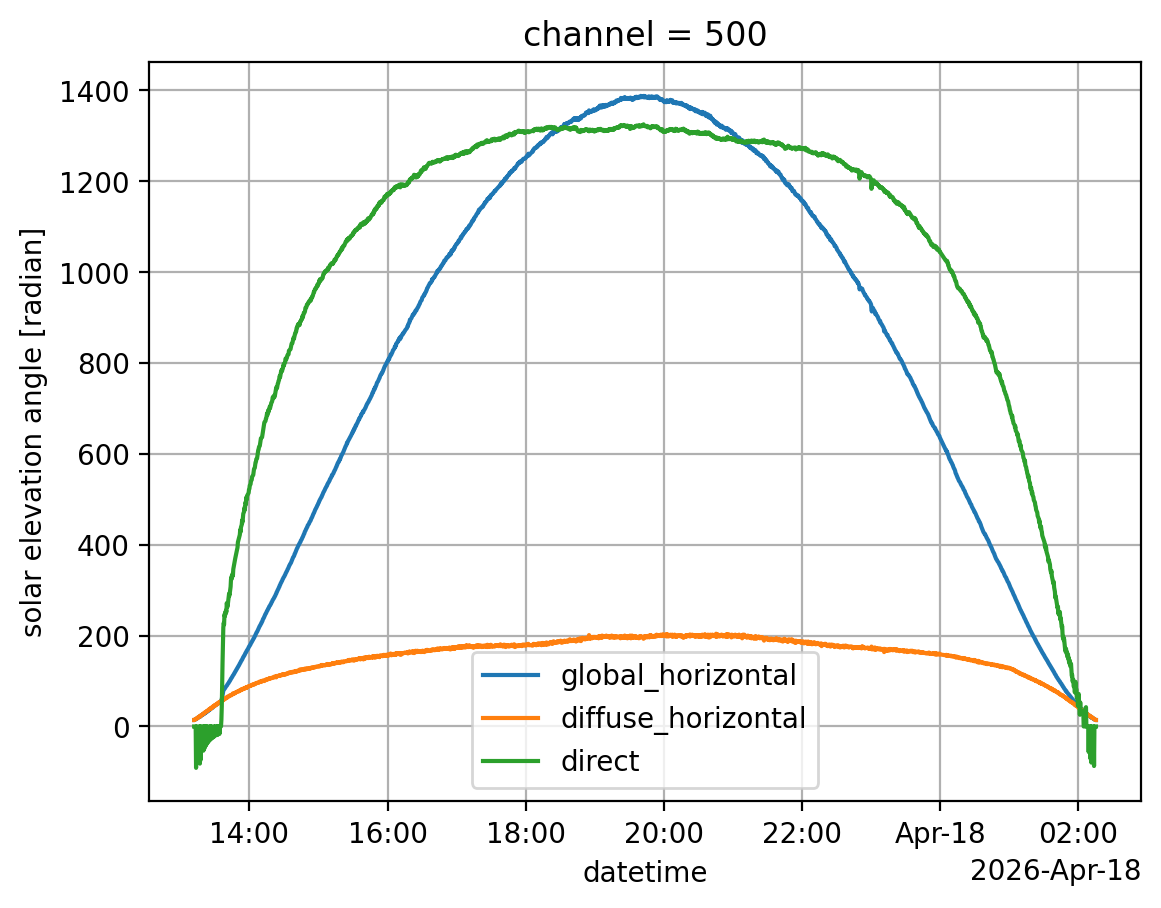

In [4]:
site = 'dra'
if 0:
    # i = -2
    # i = 12 # 2026-03-04 strange spike
    # i = 15
    i -= 1
    p2fld = pl.Path(f'/Volumes/grad/Inst/MFR/SURFRAD/{site}/mfrsr/cosine_corrected/v0.2/2026/')
    fl = list(p2fld.glob('*.nc'))
    fl.sort()
    ds = xr.open_mfdataset(fl[slice(i,i+2)])
else:
    i = None 
    fl = [f'/Volumes/grad/Inst/MFR/SURFRAD/{site}/mfrsr/cosine_corrected/v0.2/2026/{site}_mfrsr_cosinecorrected_20260417.nc',
          f'/Volumes/grad/Inst/MFR/SURFRAD/{site}/mfrsr/cosine_corrected/v0.2/2026/{site}_mfrsr_cosinecorrected_20260418.nc',]
    ds = xr.open_mfdataset(fl)

site = atmsite.Station(lat = ds.site_latitude, lon = ds.site_longitude, name = ds.site_name)
tdiff = pd.to_timedelta(site.time_zone['diff2UTC_of_standard_time'], 'h')
dt_local = pd.DatetimeIndex(ds.datetime + tdiff)
start = dt_local[0].ceil("D")
end = start  + pd.to_timedelta(1, 'D') - pd.to_timedelta(1, 'ns')
assert(start.date() == end.date()), f'Start ({start}) and end ({end}) timestamps are on different days, this should not happen!?!'
ds = ds.sel(datetime = slice(start - tdiff, end - tdiff))
print(i)
print(start)

# ds = xr.open_dataset(p2f)
dscc = atmsi.CombinedGlobalDiffuseDirect(ds)
dscc.plot_overview()
None

In [5]:
import atmPy.data_archives.NOAA_ESRL_GMD_GRAD.surfrad.surfrad as atmsrf

In [6]:
# si_tu = atmsrf.read_ccc(pl.Path('/Volumes/grad/Inst/MFR/SURFRAD/tbl/mfrsr/tu/2026/tbl_mfrsr_20260106_D824_3126_660.tu'), raisefilterfunctionerror=False)
si_tu = atmsrf.read_ccc(pl.Path('/Volumes/grad/Inst/MFR/SURFRAD/dra/mfrsr/tu/2026/dra_mfrsr_20260417_2089_718C_669.tu'), raisefilterfunctionerror=False)
tu_raw = si_tu.dataset.copy()
si_tu.dataset = si_tu.dataset.reindex(datetime = dscc.dataset.datetime, method='bfill')
si_tu.dataset = si_tu.dataset.rename({'direct_normal_irradiation': 'direct_normal', 'diffuse_horizontal_irradiation': 'diffuse_horizontal', 'global_horizontal_irradiation': 'global_horizontal'})

Text(0, 0.5, 'irradiance (mV)')

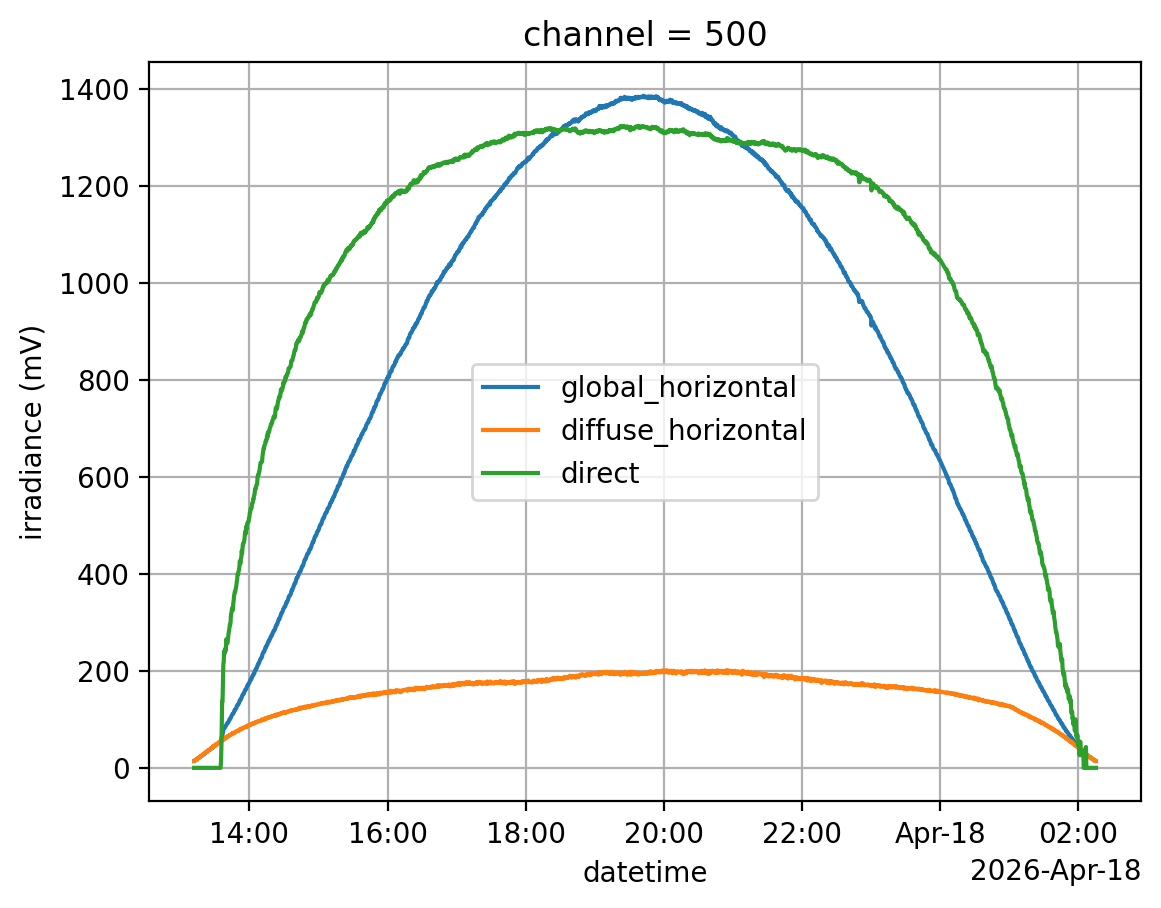

In [7]:
f,a = si_tu.plot_overview(channel=500)
a.set_ylabel('irradiance (mV)')

In [9]:
%matplotlib inline

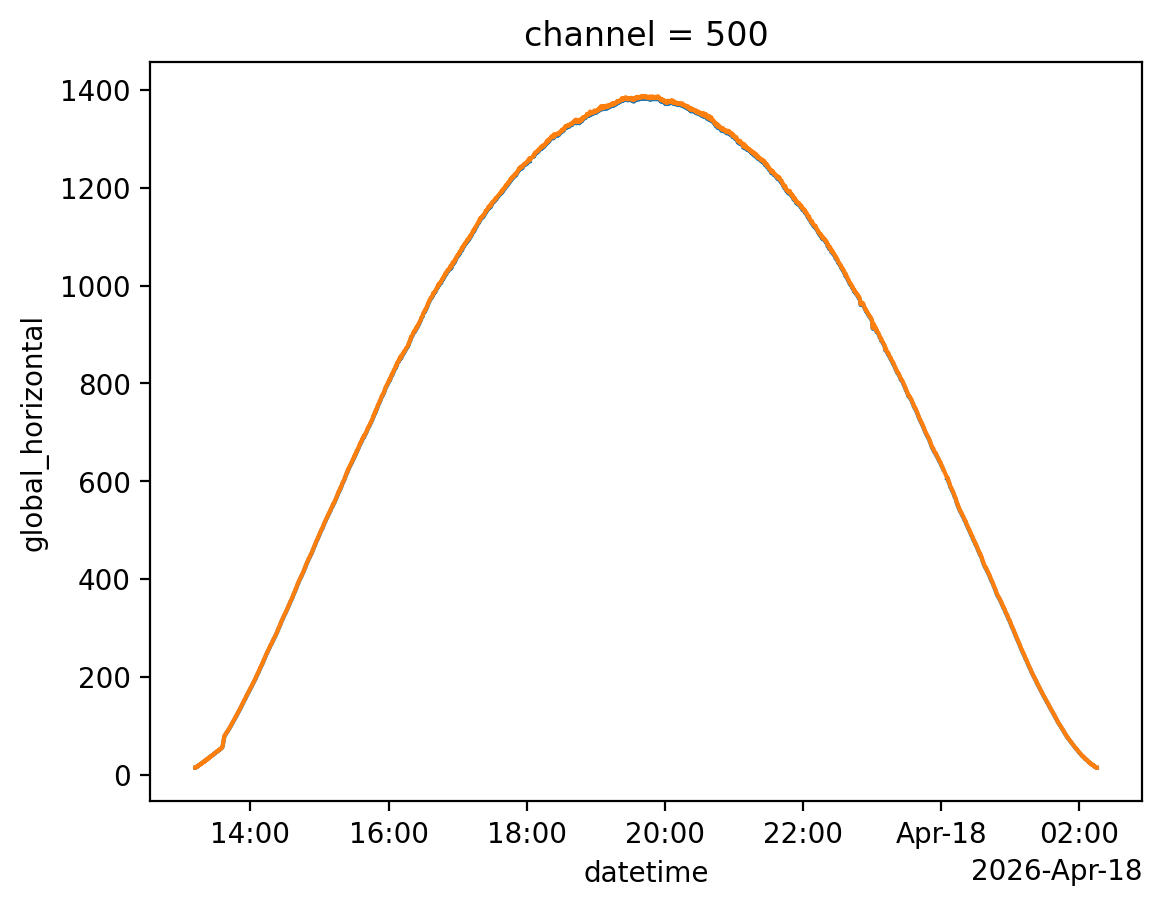

In [10]:
f,a = plt.subplots()
wl = 500
tu_raw.global_horizontal_irradiation.sel(channel = wl).plot(ax = a)
# dscc.dataset.global_horizontal_irradiation.sel(channel = wl).plot(ax = a)
dscc.dataset.global_horizontal.sel(channel = wl).plot(ax = a)

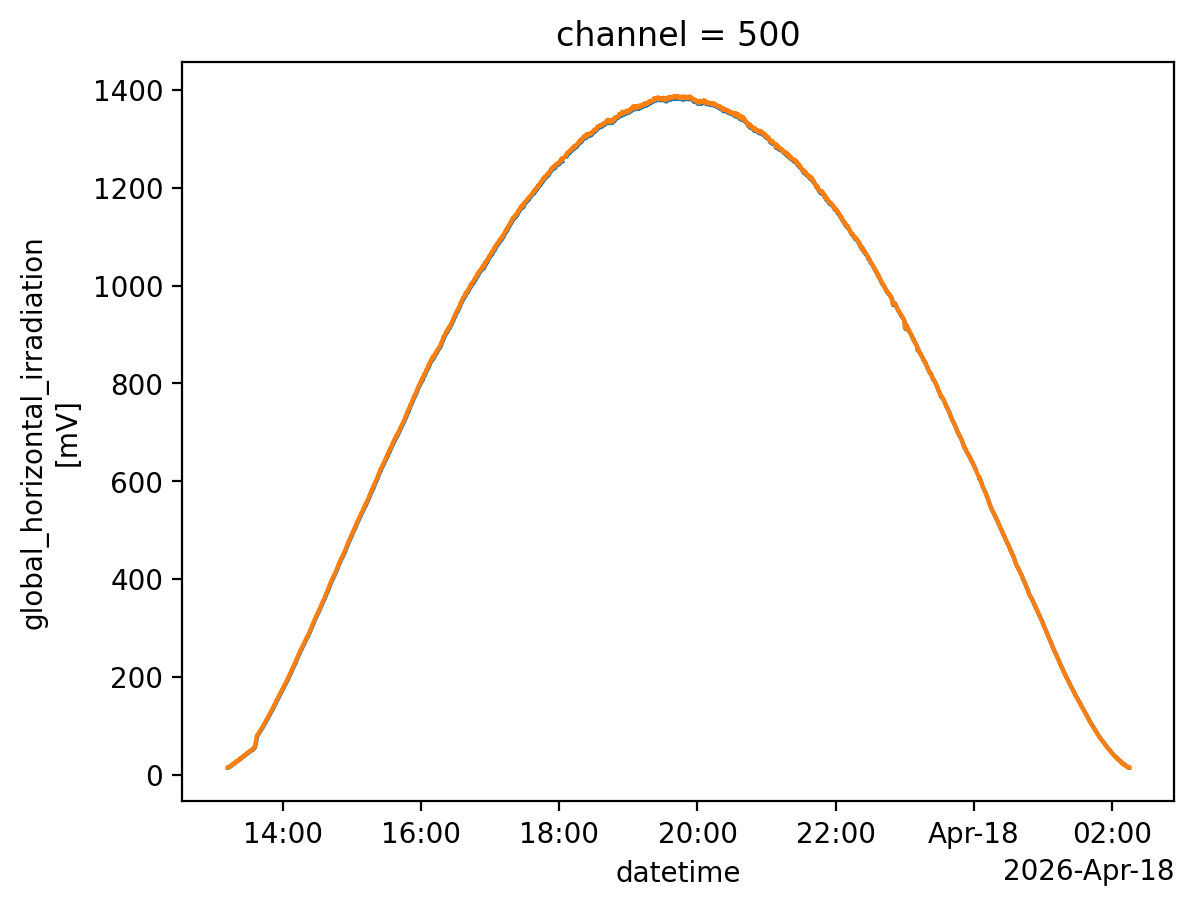

In [11]:
f,a = plt.subplots()
wl = 500
tu_raw.global_horizontal_irradiation.sel(channel = wl).plot(ax = a)
# dscc.dataset.global_horizontal_irradiation.sel(channel = wl).plot(ax = a)
das = dscc.dataset.global_horizontal.sel(channel = wl)
a.plot(das.datetime - pd.to_timedelta(20, 's'), das)

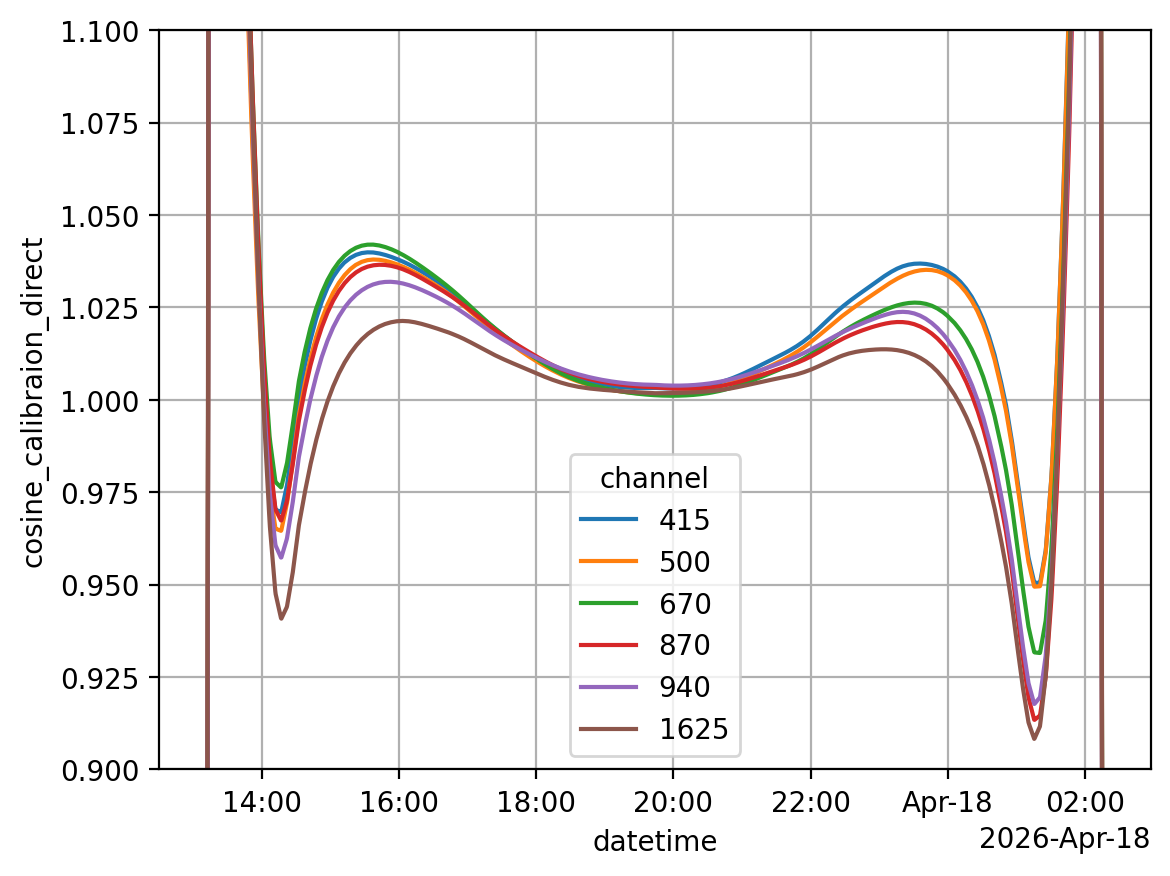

In [12]:
f,a = plt.subplots()
dscc.dataset.cosine_calibraion_direct.plot.line(x = 'datetime', ax = a)
a.set_ylim(0.9, 1.1)
a.grid(True)

(1.0, 5.0)

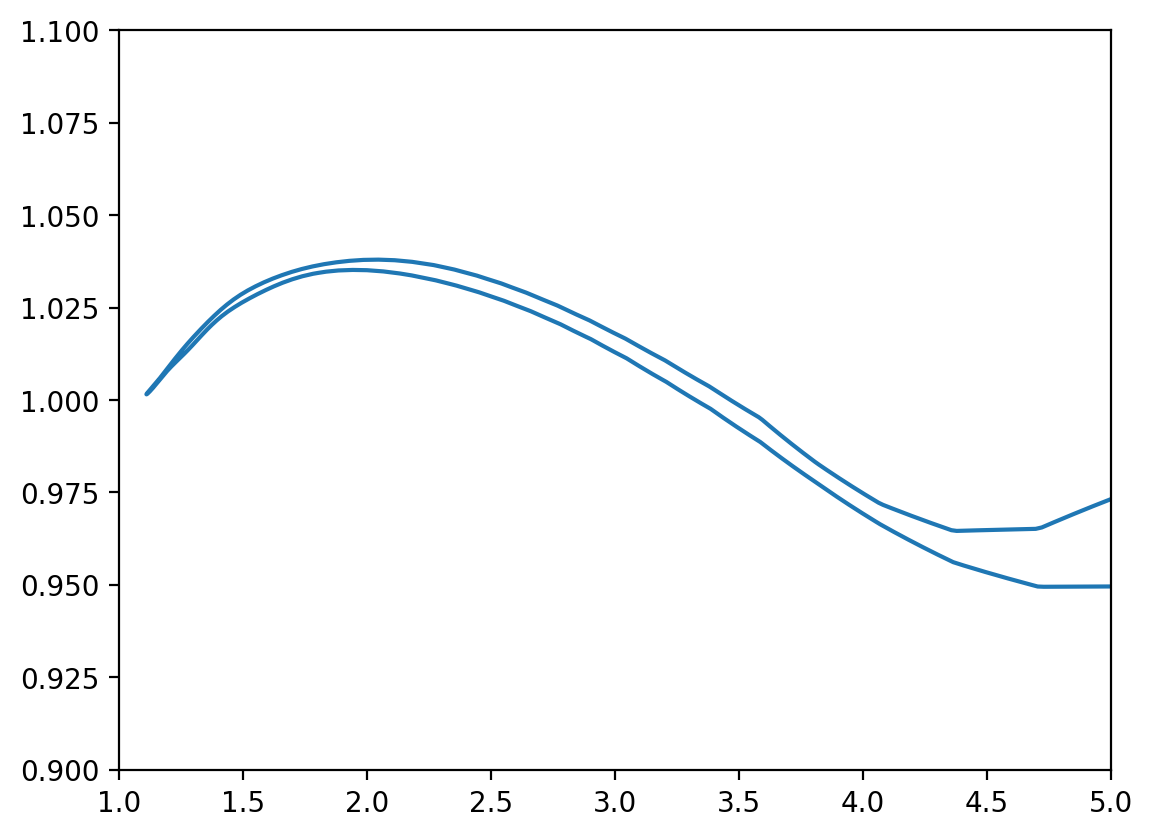

In [36]:
f,a = plt.subplots()
a.plot(dscc.dataset.airmass,dscc.dataset.cosine_calibraion_direct.sel(channel = 500))
a.set_ylim(0.9,1.1)
a.set_xlim(1,5)

/Users/htelg/miniconda3/envs/py13/lib/python3.13/site-packages/dask/_task_spec.py:768: RuntimeWarning: divide by zero encountered in divide
  return self.func(*new_argspec)
/Users/htelg/miniconda3/envs/py13/lib/python3.13/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


(1.0, 5.0)

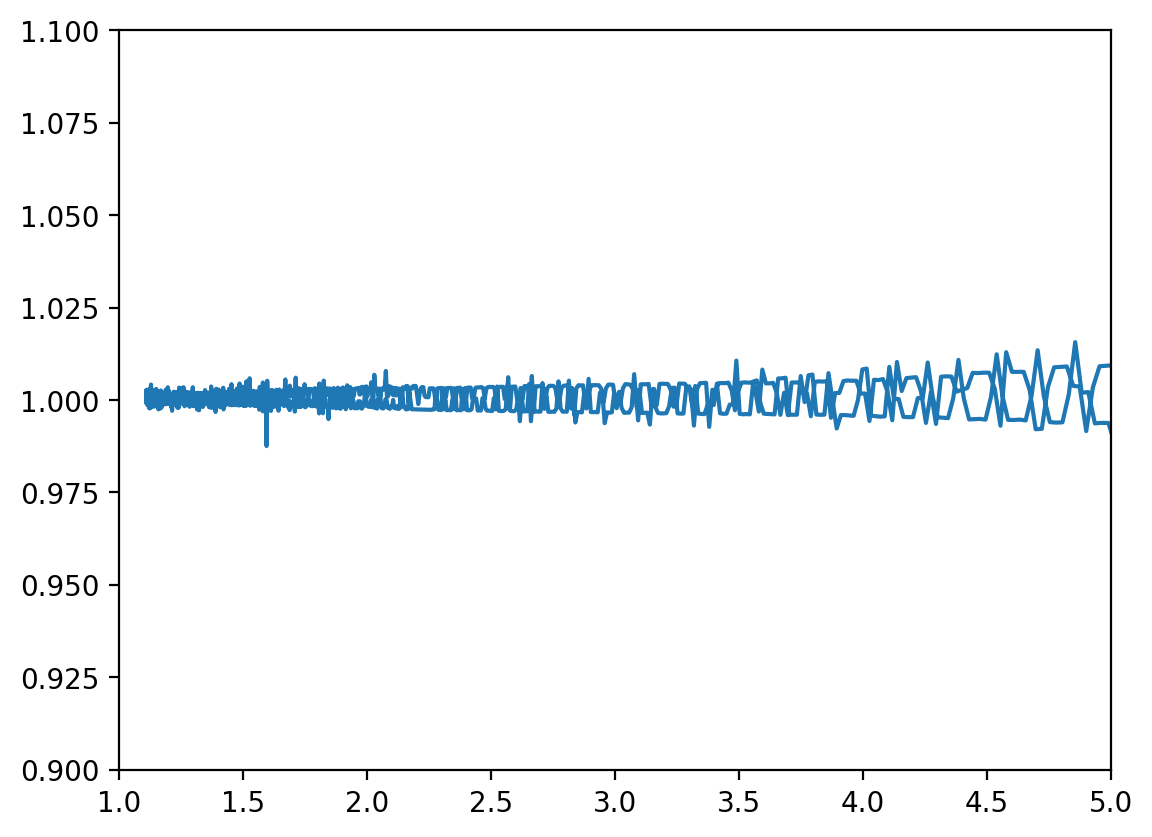

In [40]:
wl = 415
dacc = dscc.dataset.direct_normal.sel(channel= wl)
datu = si_tu.dataset.direct_normal.sel(channel = wl)

datu = datu.reindex(datetime = dacc.datetime, method = 'closest')

f,a = plt.subplots()
a.plot(dscc.dataset.airmass, dacc/datu)
a.set_ylim(0.9,1.1)
a.set_xlim(1,5)

/Users/htelg/miniconda3/envs/py13/lib/python3.13/site-packages/dask/_task_spec.py:768: RuntimeWarning: divide by zero encountered in divide
  return self.func(*new_argspec)
/Users/htelg/miniconda3/envs/py13/lib/python3.13/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


(1.0, 5.0)

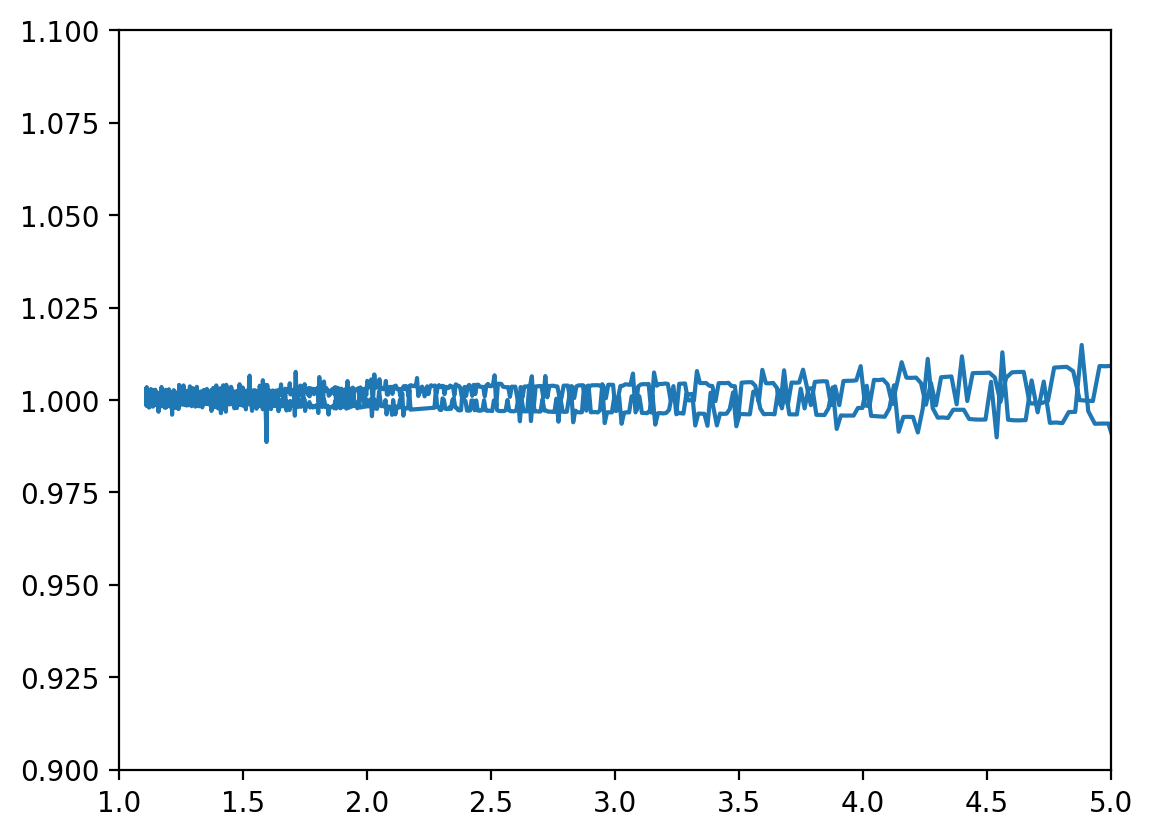

In [41]:
wl = 500
dacc = dscc.dataset.direct_normal.sel(channel= wl)
datu = si_tu.dataset.direct_normal.sel(channel = wl)

datu = datu.reindex(datetime = dacc.datetime, method = 'closest')

f,a = plt.subplots()
a.plot(dscc.dataset.airmass, dacc/datu)
a.set_ylim(0.9,1.1)
a.set_xlim(1,5)

/Users/htelg/miniconda3/envs/py13/lib/python3.13/site-packages/dask/_task_spec.py:768: RuntimeWarning: divide by zero encountered in divide
  return self.func(*new_argspec)
/Users/htelg/miniconda3/envs/py13/lib/python3.13/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


(1.0, 5.0)

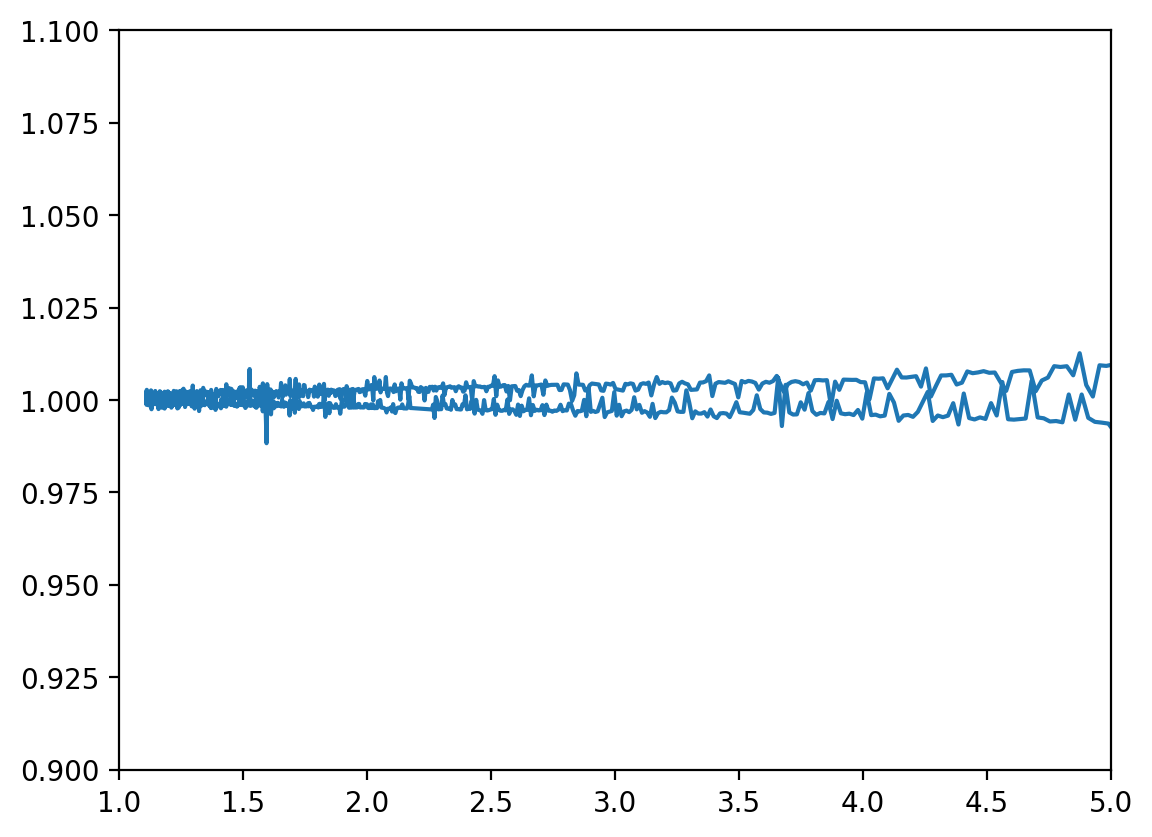

In [42]:
wl = 670
dacc = dscc.dataset.direct_normal.sel(channel= wl)
datu = si_tu.dataset.direct_normal.sel(channel = wl)

datu = datu.reindex(datetime = dacc.datetime, method = 'closest')

f,a = plt.subplots()
a.plot(dscc.dataset.airmass, dacc/datu)
a.set_ylim(0.9,1.1)
a.set_xlim(1,5)

/Users/htelg/miniconda3/envs/py13/lib/python3.13/site-packages/dask/_task_spec.py:768: RuntimeWarning: divide by zero encountered in divide
  return self.func(*new_argspec)
/Users/htelg/miniconda3/envs/py13/lib/python3.13/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


(1.0, 5.0)

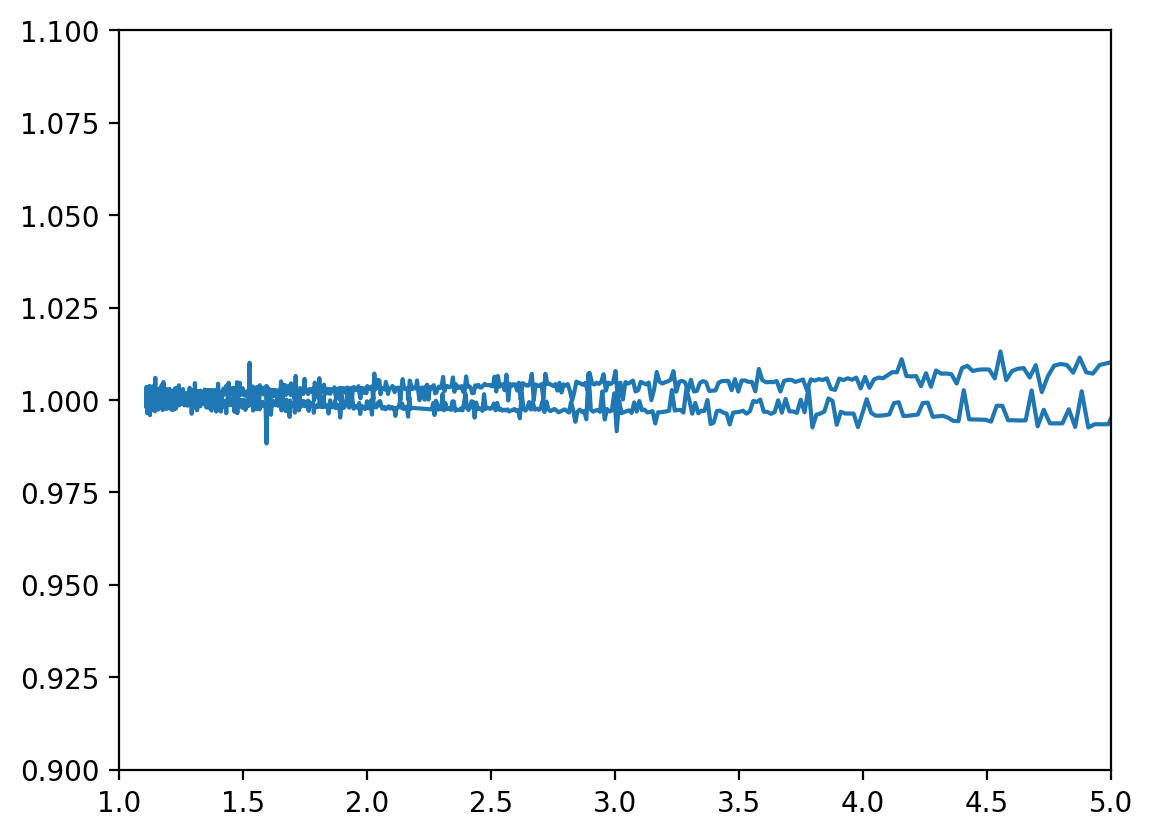

In [43]:
wl = 870
dacc = dscc.dataset.direct_normal.sel(channel= wl)
datu = si_tu.dataset.direct_normal.sel(channel = wl)

datu = datu.reindex(datetime = dacc.datetime, method = 'closest')

f,a = plt.subplots()
a.plot(dscc.dataset.airmass, dacc/datu)
a.set_ylim(0.9,1.1)
a.set_xlim(1,5)

/Users/htelg/miniconda3/envs/py13/lib/python3.13/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/Users/htelg/miniconda3/envs/py13/lib/python3.13/site-packages/dask/_task_spec.py:768: RuntimeWarning: divide by zero encountered in divide
  return self.func(*new_argspec)


(1.0, 5.0)

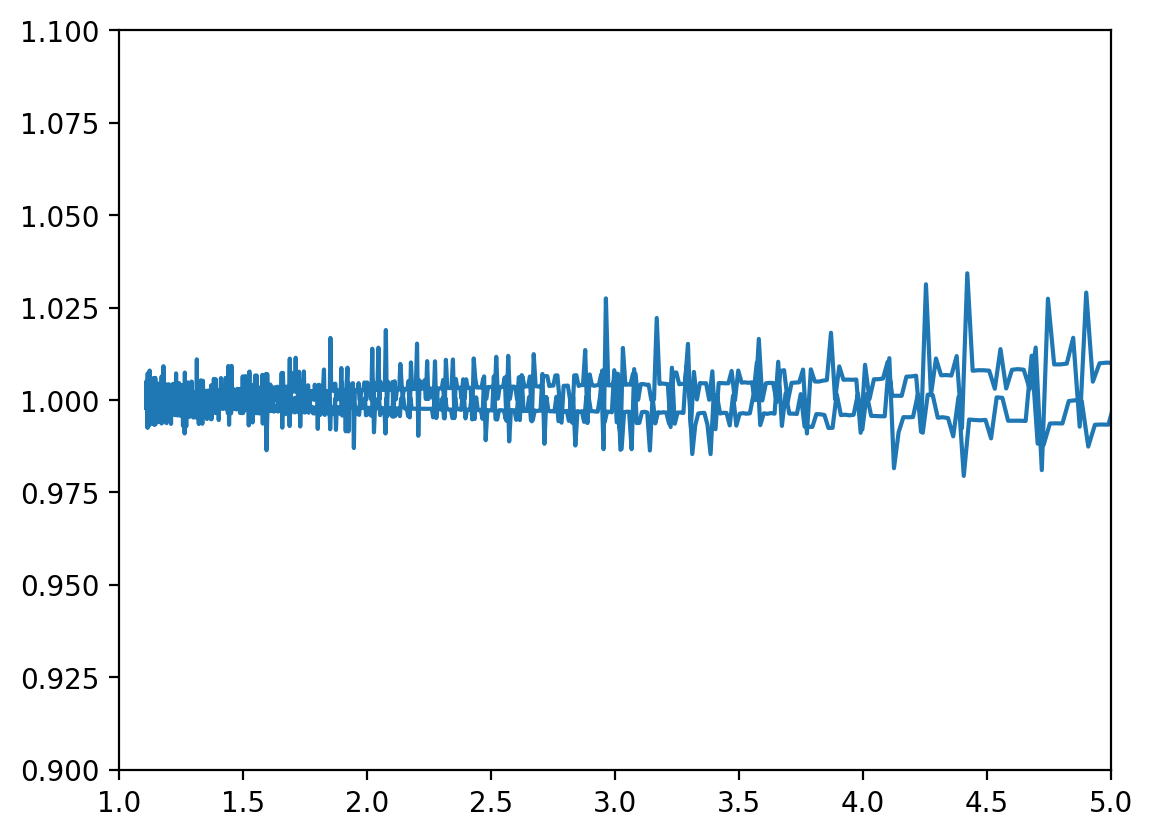

In [44]:
wl = 1625
dacc = dscc.dataset.direct_normal.sel(channel= wl)
datu = si_tu.dataset.direct_normal.sel(channel = wl)

datu = datu.reindex(datetime = dacc.datetime, method = 'closest')

f,a = plt.subplots()
a.plot(dscc.dataset.airmass, dacc/datu)
a.set_ylim(0.9,1.1)
a.set_xlim(1,5)

In [45]:
wl = 870
dacc = dscc.dataset.direct_normal.sel(channel= wl)
datu = si_tu.dataset.direct_normal.sel(channel = wl)

In [46]:
datu = datu.reindex(datetime = dacc.datetime, method = 'closest')

/Users/htelg/miniconda3/envs/py13/lib/python3.13/site-packages/dask/_task_spec.py:768: RuntimeWarning: divide by zero encountered in divide
  return self.func(*new_argspec)
/Users/htelg/miniconda3/envs/py13/lib/python3.13/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


(1.0, 5.0)

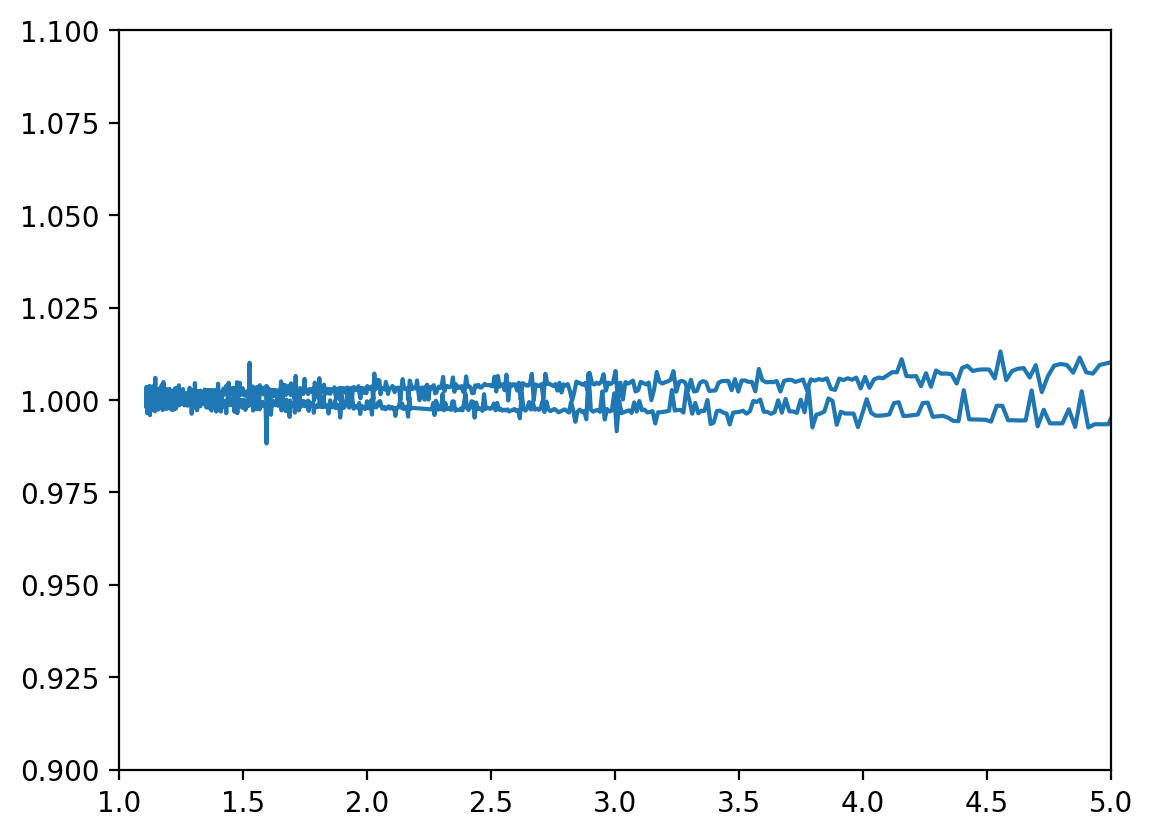

In [47]:
f,a = plt.subplots()
a.plot(dscc.dataset.airmass, dacc/datu)
a.set_ylim(0.9,1.1)
a.set_xlim(1,5)

# Langleys

In [127]:
%matplotlib inline

## am

In [14]:
amr = [2.2,5]

In [15]:
dscc.direct_normal_irradiation._am = None
dscc.direct_normal_irradiation._pm = None
dscc.direct_normal_irradiation.settings_langley_airmass_limits = amr

In [16]:
si_tu.direct_normal_irradiation._am = None
si_tu.direct_normal_irradiation._pm = None
si_tu.direct_normal_irradiation.settings_langley_airmass_limits = amr

original columns: ['apparent_zenith', 'zenith', 'apparent_elevation', 'elevation', 'azimuth', 'equation_of_time']


/Users/htelg/miniconda3/envs/py13/lib/python3.13/site-packages/dask/_task_spec.py:768: RuntimeWarning: divide by zero encountered in log
  return self.func(*new_argspec)
/Users/htelg/miniconda3/envs/py13/lib/python3.13/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in log
  return self.func(*new_argspec)
/Users/htelg/miniconda3/envs/py13/lib/python3.13/site-packages/dask/_task_spec.py:768: RuntimeWarning: divide by zero encountered in log
  return self.func(*new_argspec)
/Users/htelg/miniconda3/envs/py13/lib/python3.13/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in log
  return self.func(*new_argspec)


(<Figure size 1280x960 with 1 Axes>, <Axes: xlabel='airmass'>)

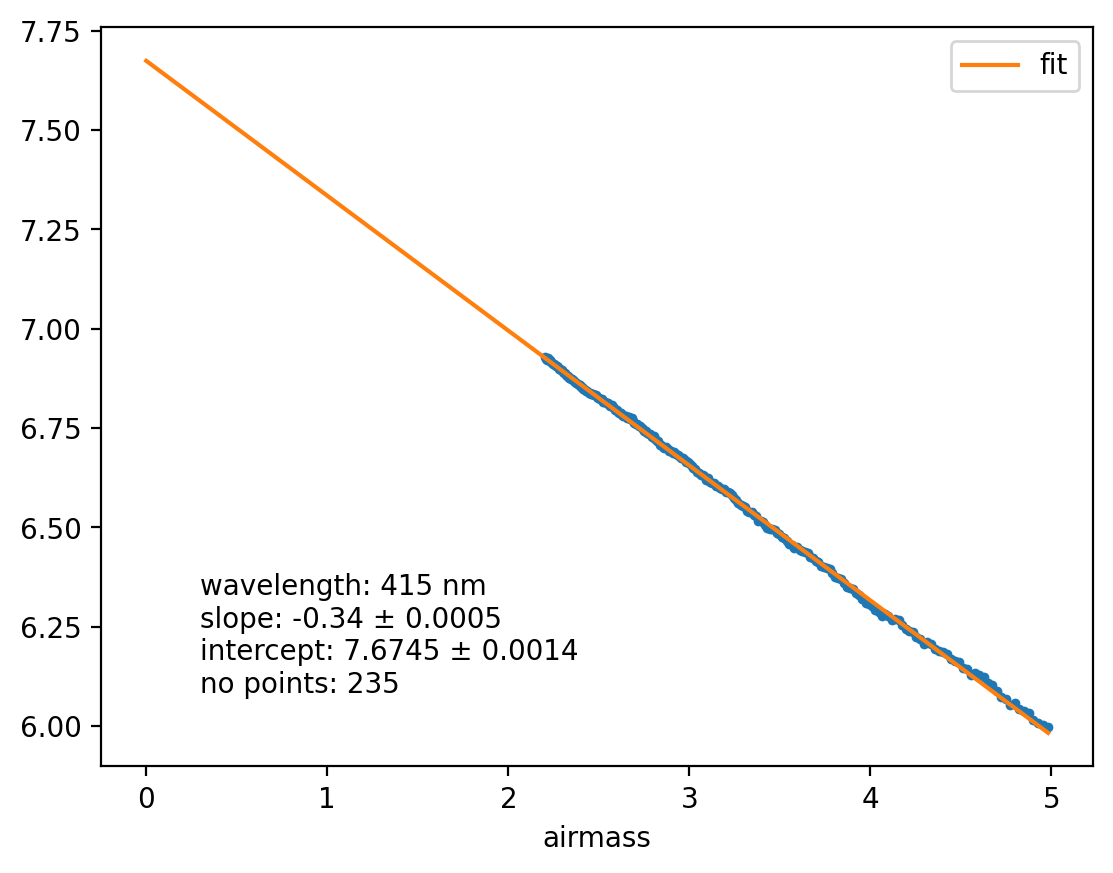

In [17]:
dscc.direct_normal_irradiation.langley_am.plot(wavelength=415, show_pre_clean=False)

original columns: ['apparent_zenith', 'zenith', 'apparent_elevation', 'elevation', 'azimuth', 'equation_of_time']


/Users/htelg/miniconda3/envs/py13/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:820: RuntimeWarning: divide by zero encountered in log
  result_data = func(*input_data)


(<Figure size 1280x960 with 1 Axes>, <Axes: xlabel='airmass'>)

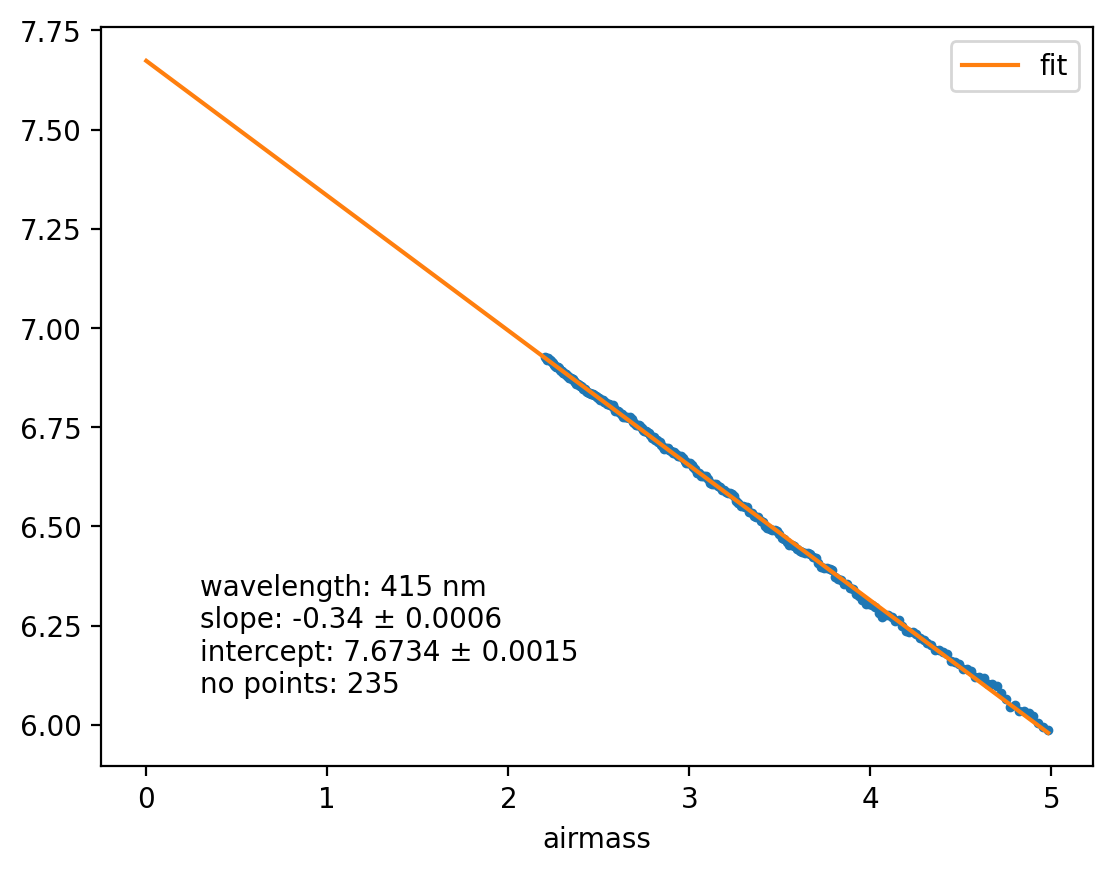

In [18]:
si_tu.direct_normal_irradiation.langley_am.plot(wavelength=415, show_pre_clean=False)

(<Figure size 1280x960 with 1 Axes>, <Axes: xlabel='airmass'>)

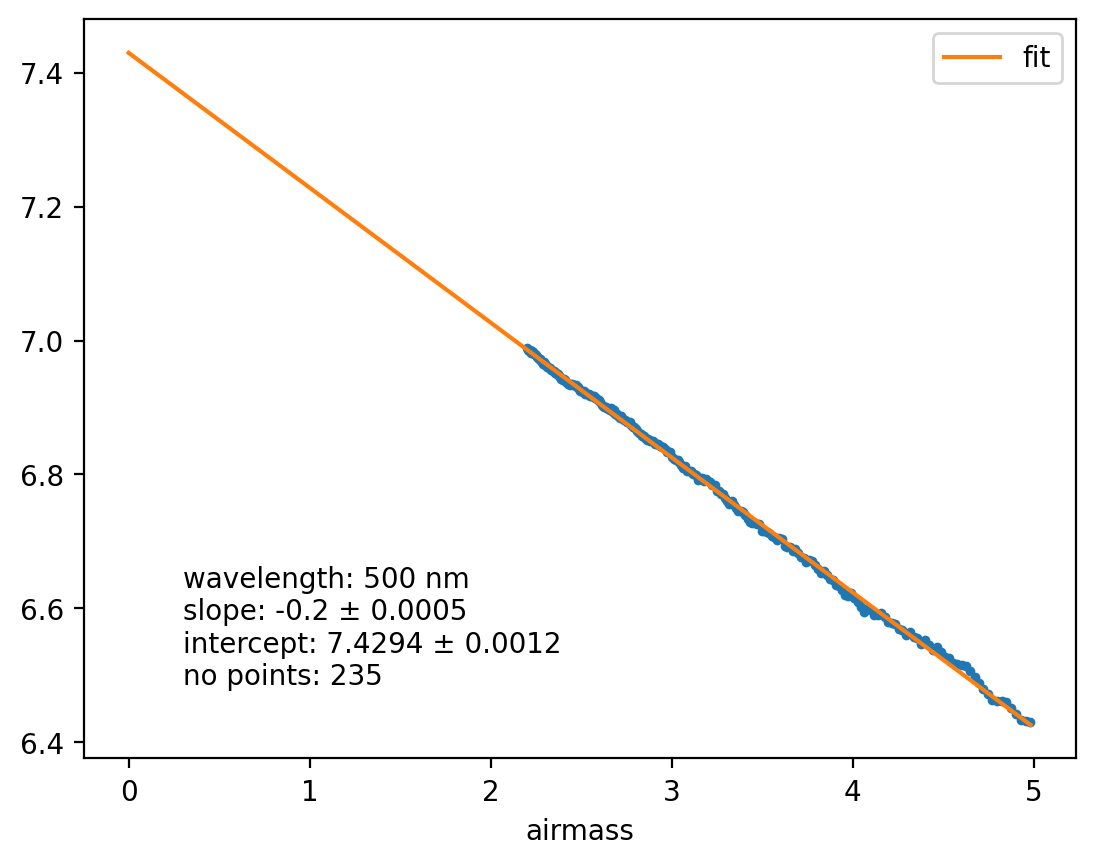

In [19]:
dscc.direct_normal_irradiation.langley_am.plot(wavelength=500, show_pre_clean=False)

(<Figure size 1280x960 with 1 Axes>, <Axes: xlabel='airmass'>)

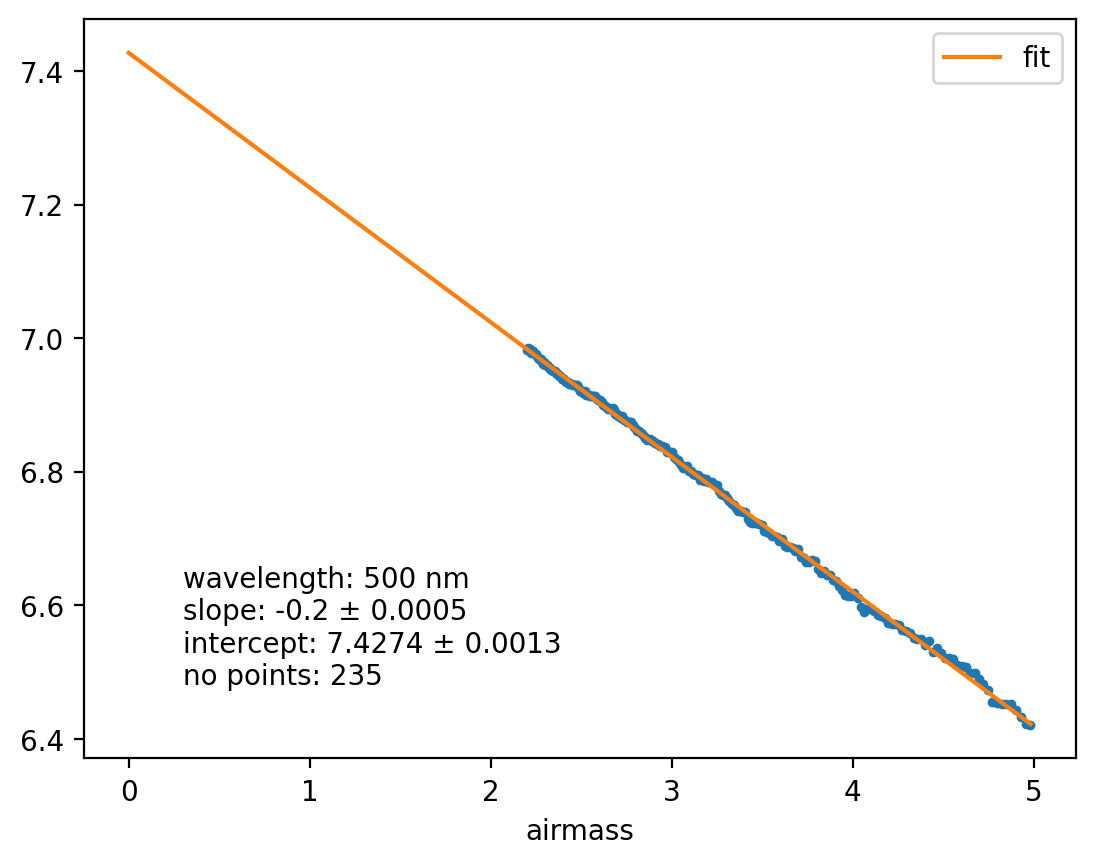

In [20]:
si_tu.direct_normal_irradiation.langley_am.plot(wavelength=500, show_pre_clean=False)

(<Figure size 1280x960 with 1 Axes>, <Axes: xlabel='airmass'>)

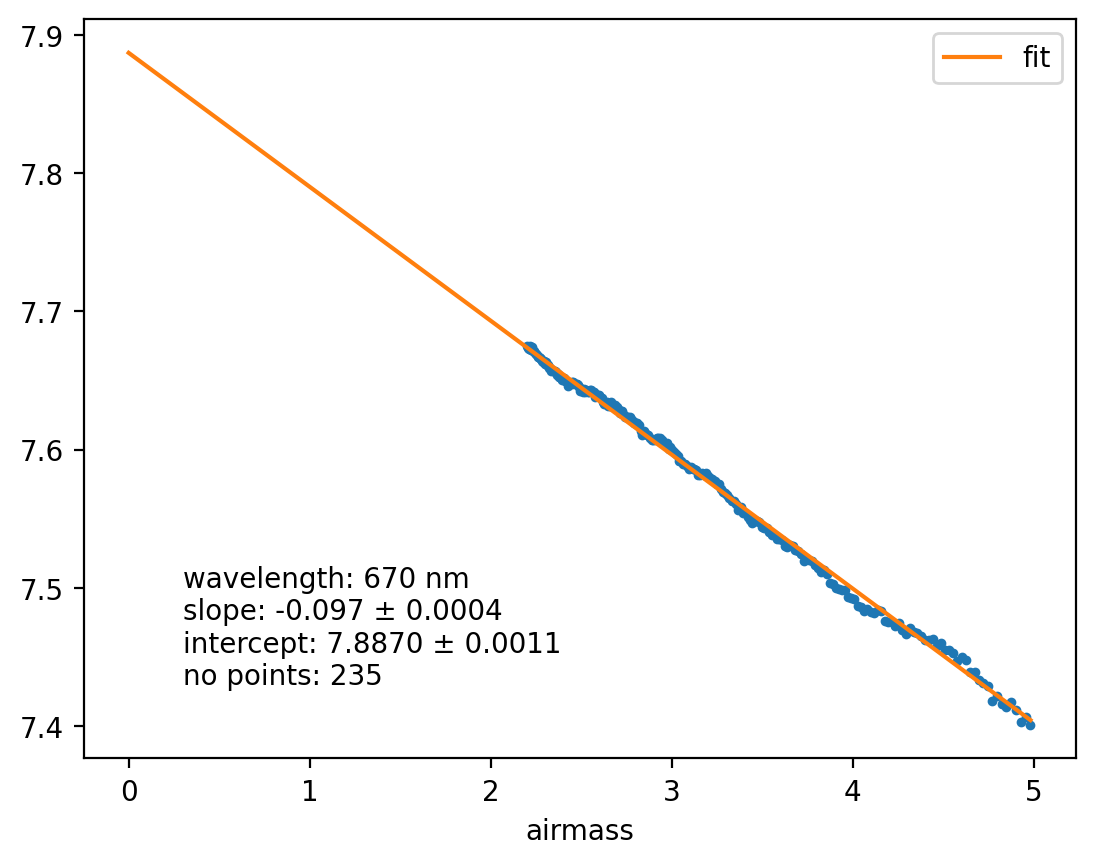

In [21]:
dscc.direct_normal_irradiation.langley_am.plot(wavelength=670, show_pre_clean=False)

(<Figure size 1280x960 with 1 Axes>, <Axes: xlabel='airmass'>)

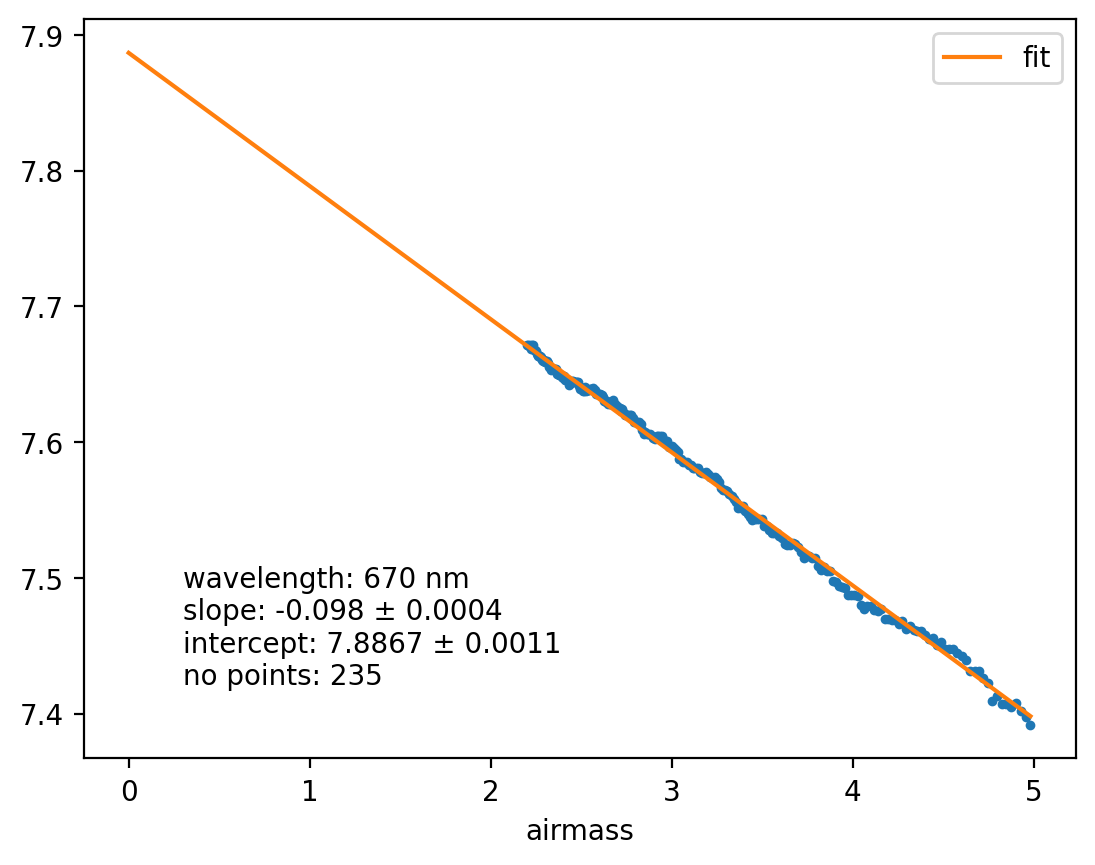

In [22]:
si_tu.direct_normal_irradiation.langley_am.plot(wavelength=670, show_pre_clean=False)

(<Figure size 1280x960 with 1 Axes>, <Axes: xlabel='airmass'>)

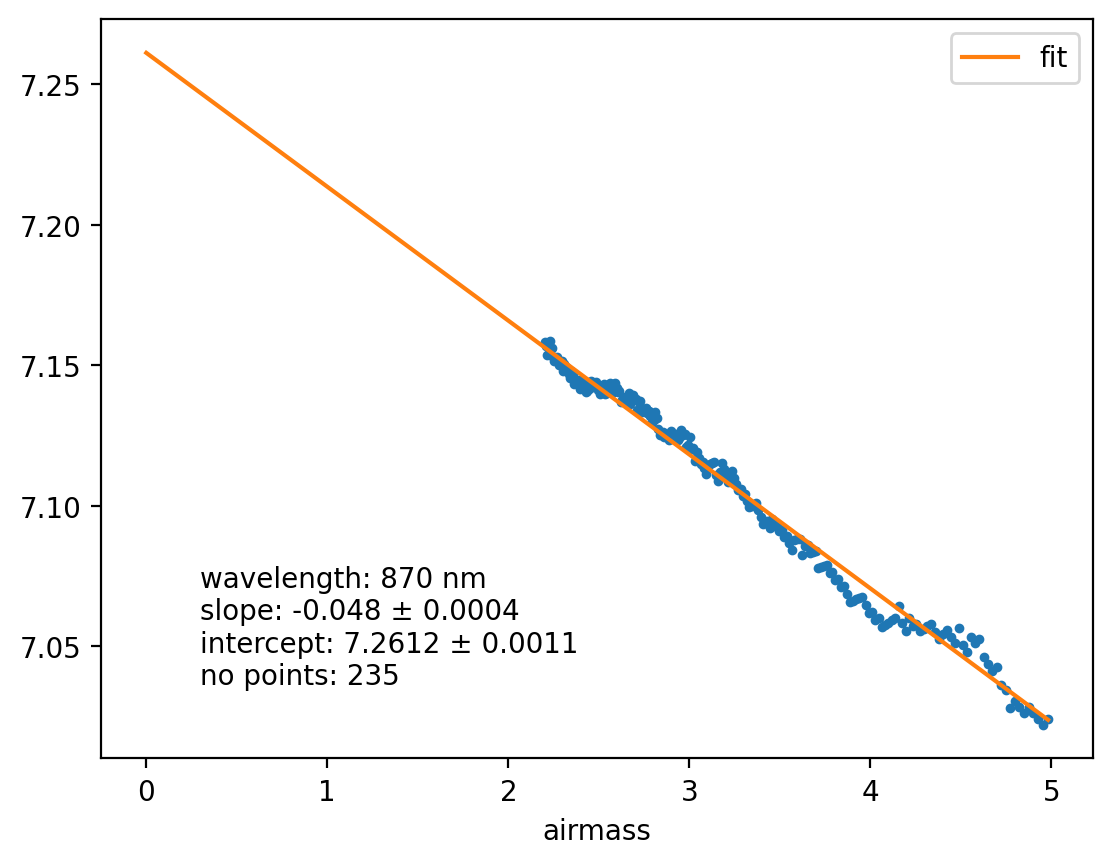

In [23]:
dscc.direct_normal_irradiation.langley_am.plot(wavelength=870, show_pre_clean=False)

(<Figure size 1280x960 with 1 Axes>, <Axes: xlabel='airmass'>)

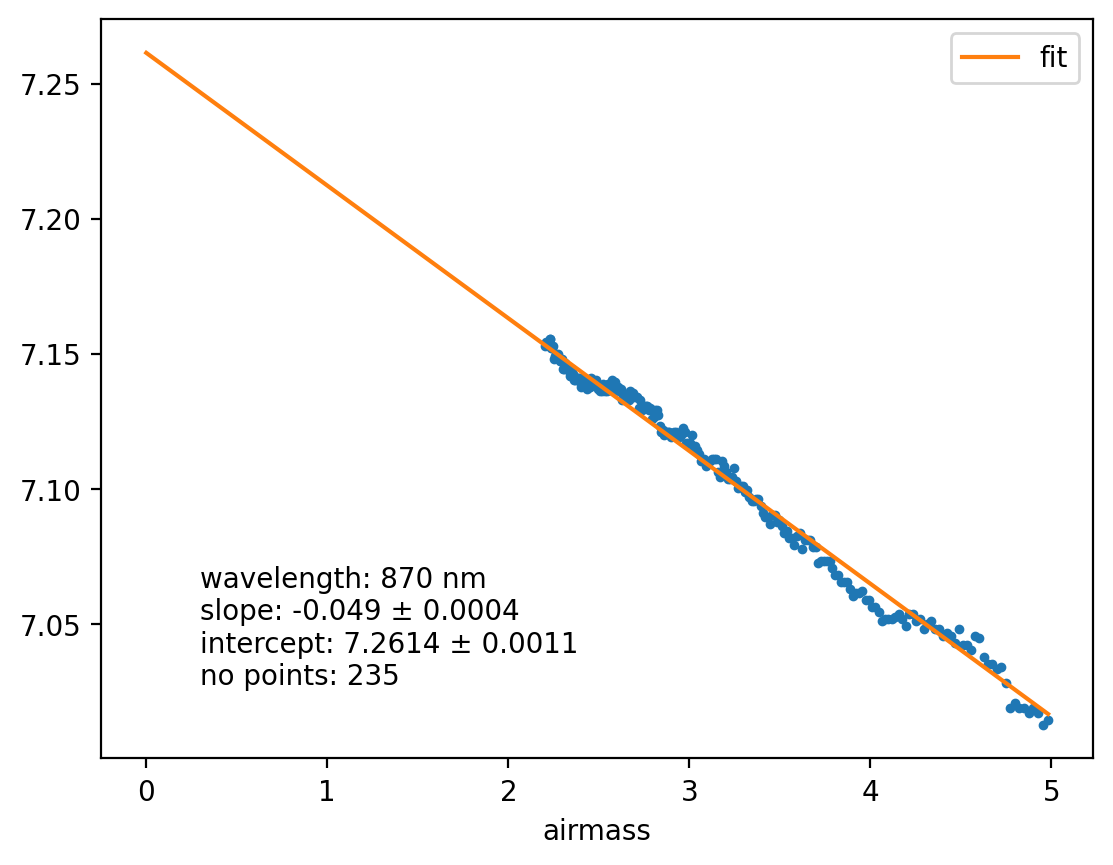

In [24]:
si_tu.direct_normal_irradiation.langley_am.plot(wavelength=870, show_pre_clean=False)

(<Figure size 1280x960 with 1 Axes>, <Axes: xlabel='airmass'>)

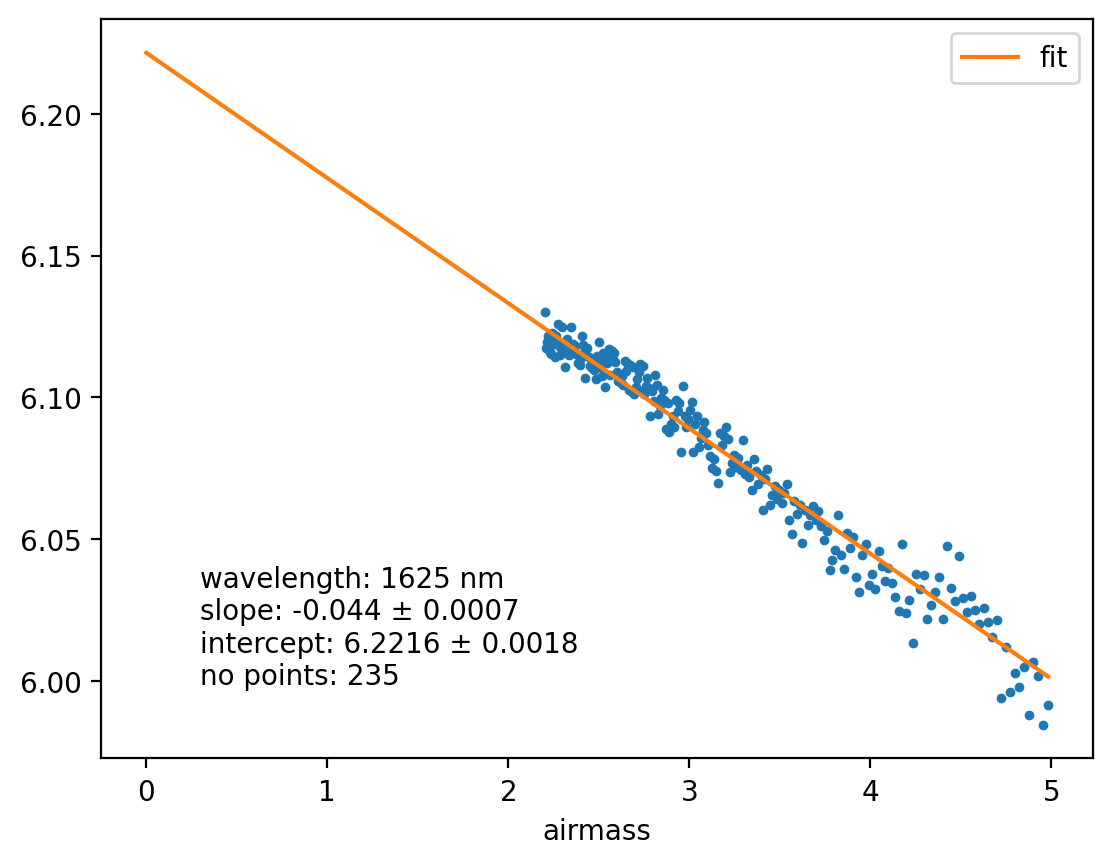

In [25]:
dscc.direct_normal_irradiation.langley_am.plot(wavelength=1625, show_pre_clean=False)

(<Figure size 1280x960 with 1 Axes>, <Axes: xlabel='airmass'>)

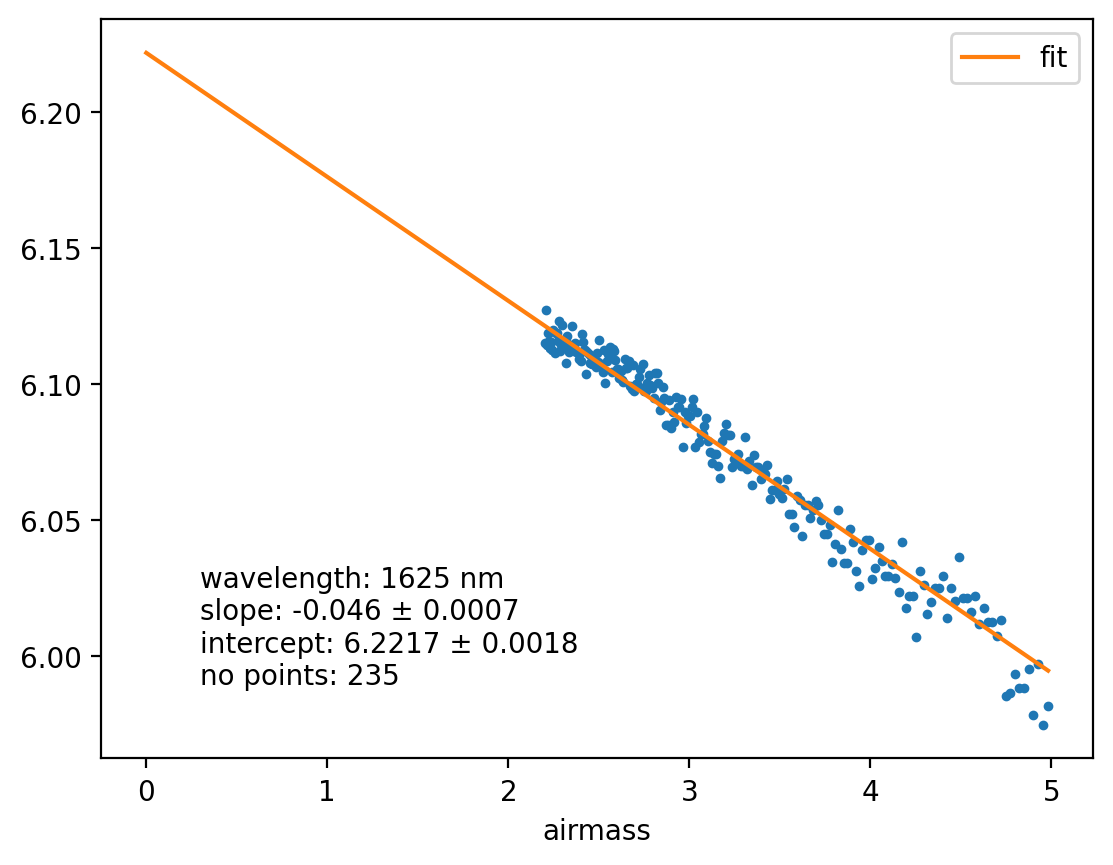

In [26]:
si_tu.direct_normal_irradiation.langley_am.plot(wavelength=1625, show_pre_clean=False)

## pm

(<Figure size 1280x960 with 1 Axes>, <Axes: xlabel='airmass'>)

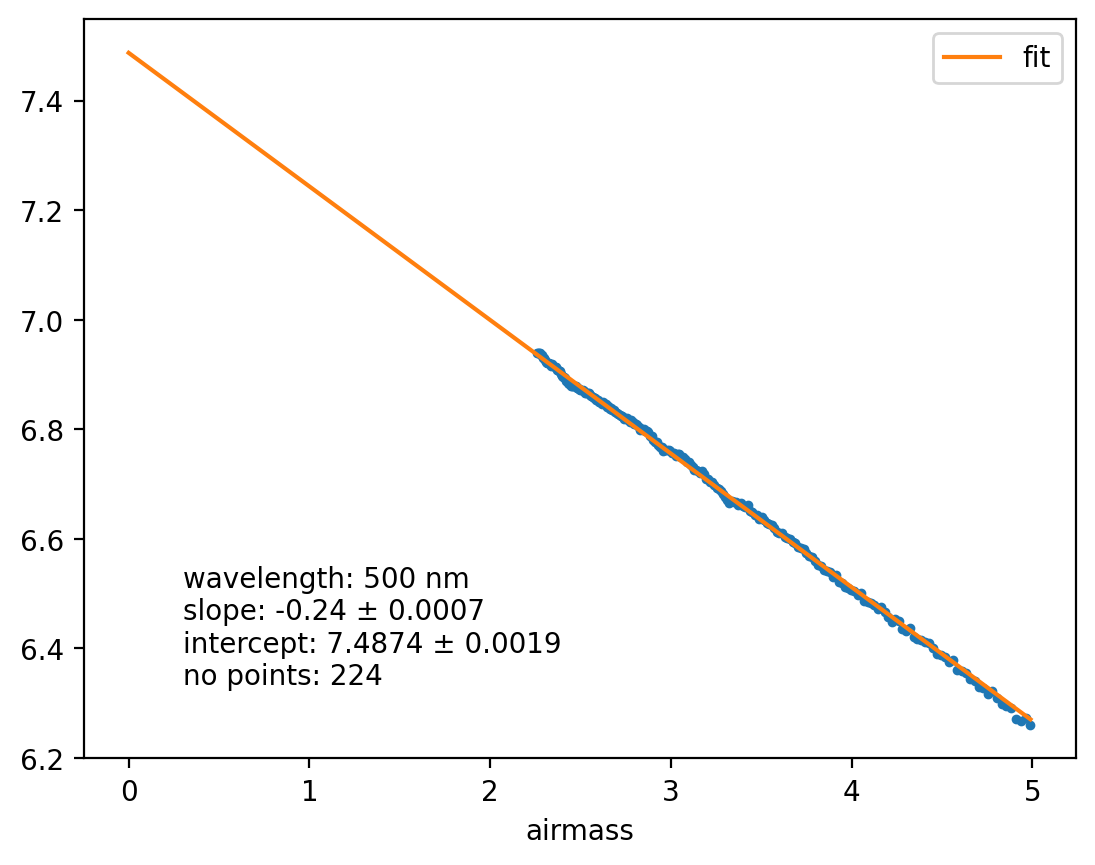

In [27]:
dscc.direct_normal_irradiation.langley_pm.plot(wavelength=500, show_pre_clean=False)

(<Figure size 1280x960 with 1 Axes>, <Axes: xlabel='airmass'>)

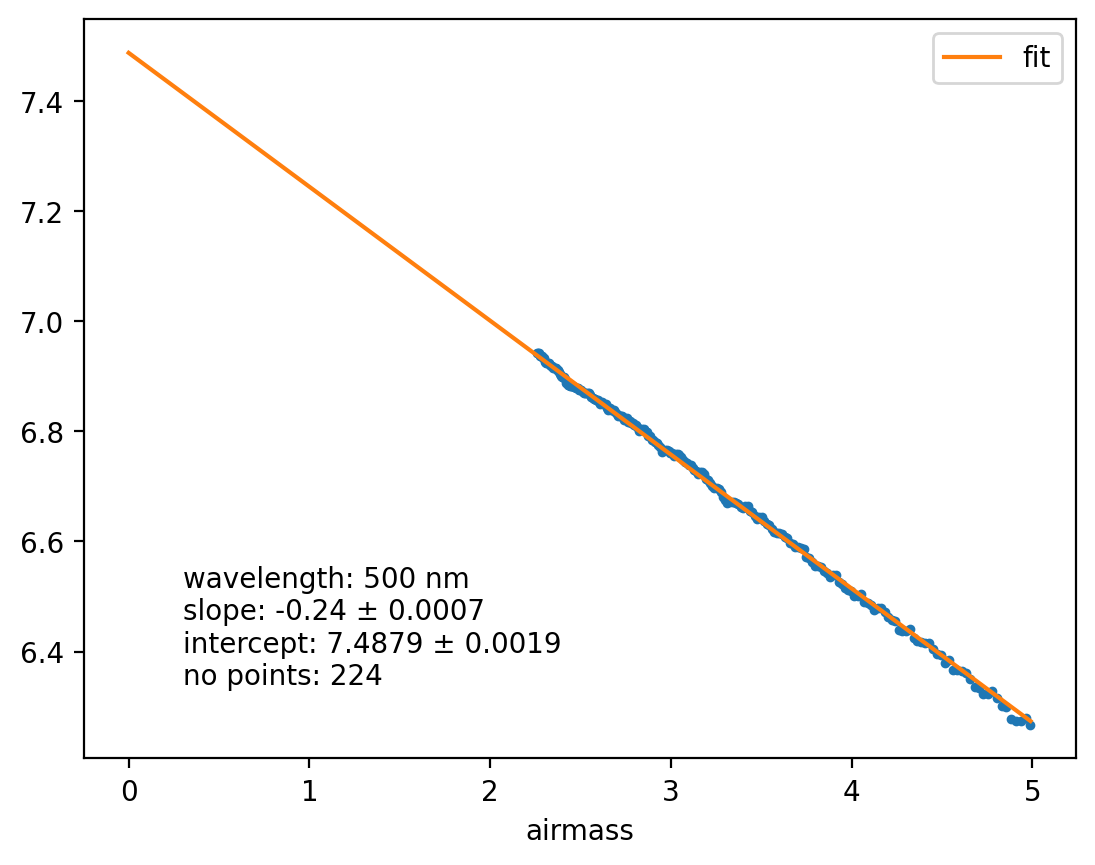

In [28]:
si_tu.direct_normal_irradiation.langley_pm.plot(wavelength=500, show_pre_clean=False)

(<Figure size 1280x960 with 1 Axes>, <Axes: xlabel='airmass'>)

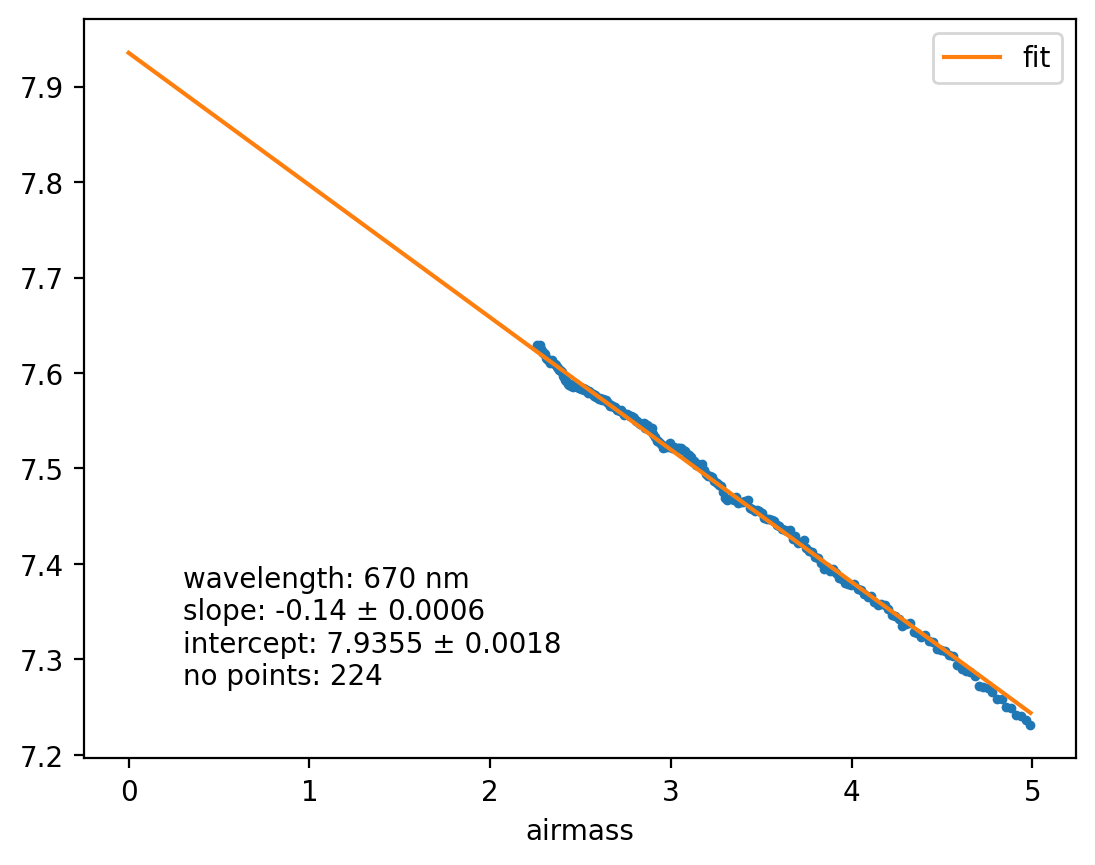

In [29]:
dscc.direct_normal_irradiation.langley_pm.plot(wavelength=670, show_pre_clean=False)

(<Figure size 1280x960 with 1 Axes>, <Axes: xlabel='airmass'>)

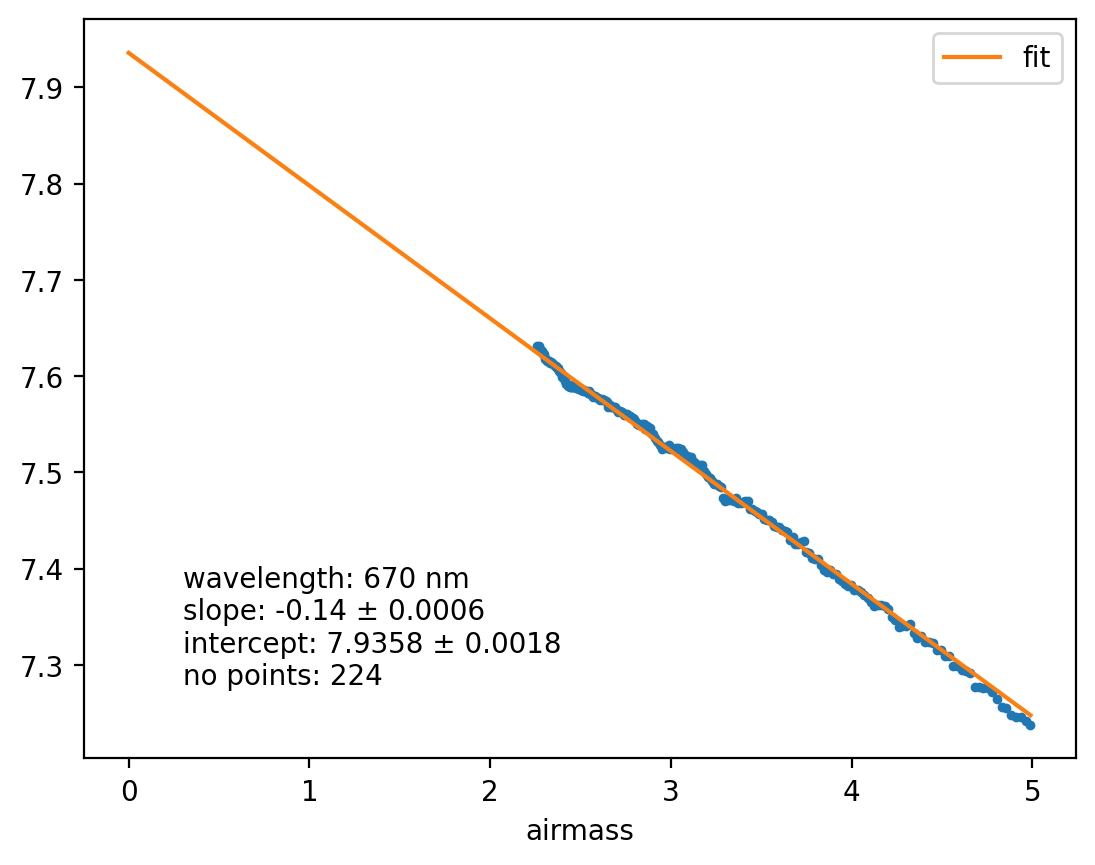

In [30]:
si_tu.direct_normal_irradiation.langley_pm.plot(wavelength=670, show_pre_clean=False)

(<Figure size 1280x960 with 1 Axes>, <Axes: xlabel='airmass'>)

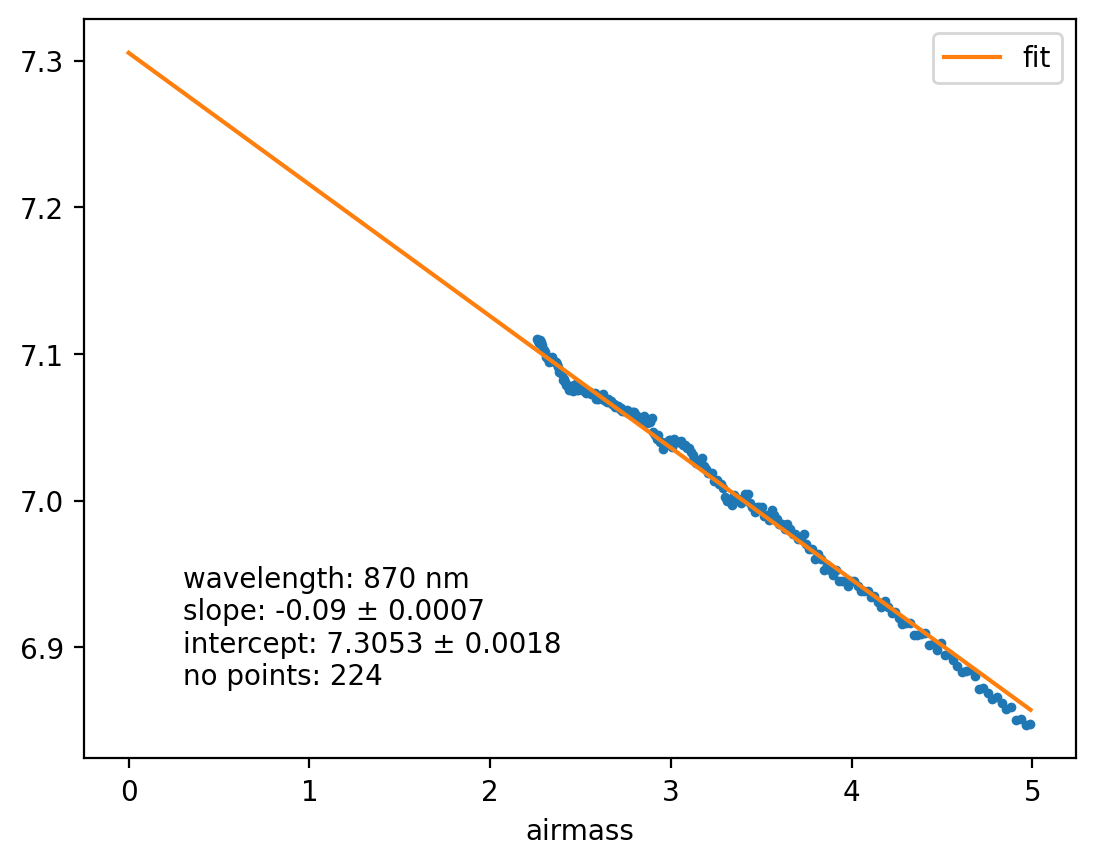

In [31]:
dscc.direct_normal_irradiation.langley_pm.plot(wavelength=870, show_pre_clean=False)

(<Figure size 1280x960 with 1 Axes>, <Axes: xlabel='airmass'>)

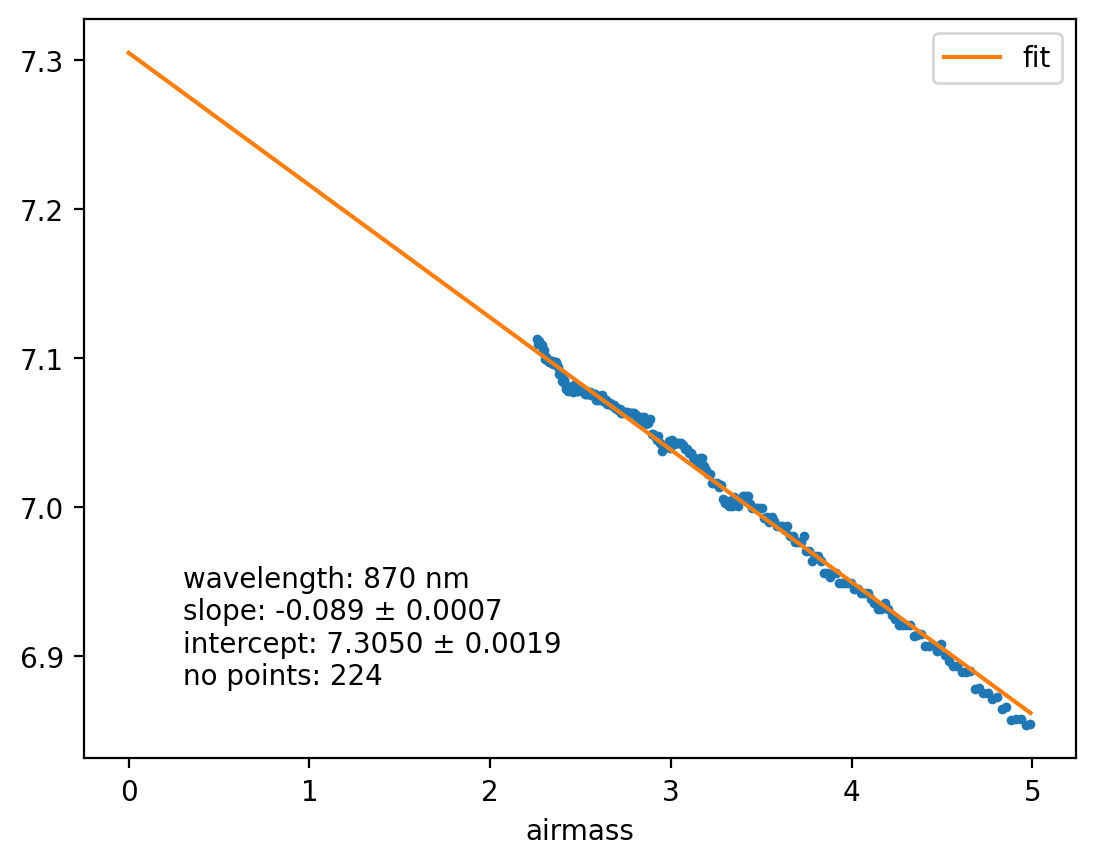

In [32]:
si_tu.direct_normal_irradiation.langley_pm.plot(wavelength=870, show_pre_clean=False)

(<Figure size 1280x960 with 1 Axes>, <Axes: xlabel='airmass'>)

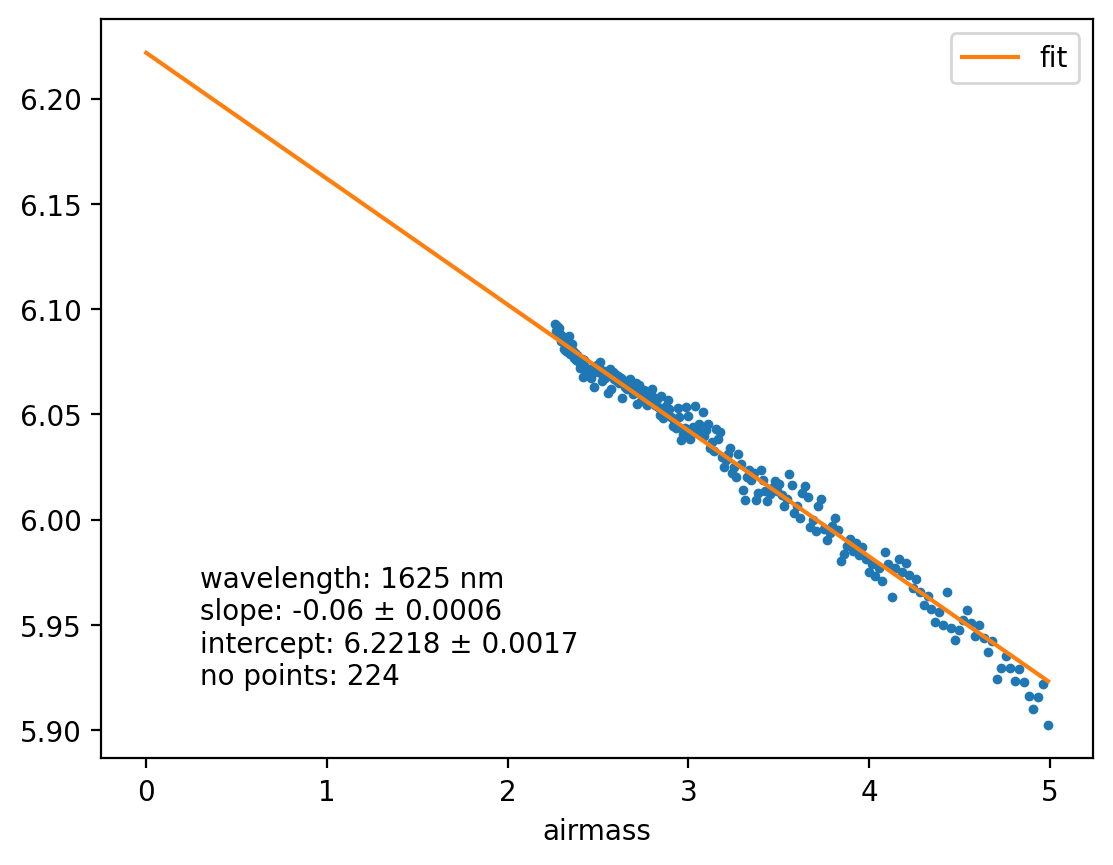

In [33]:
dscc.direct_normal_irradiation.langley_pm.plot(wavelength=1625, show_pre_clean=False)

(<Figure size 1280x960 with 1 Axes>, <Axes: xlabel='airmass'>)

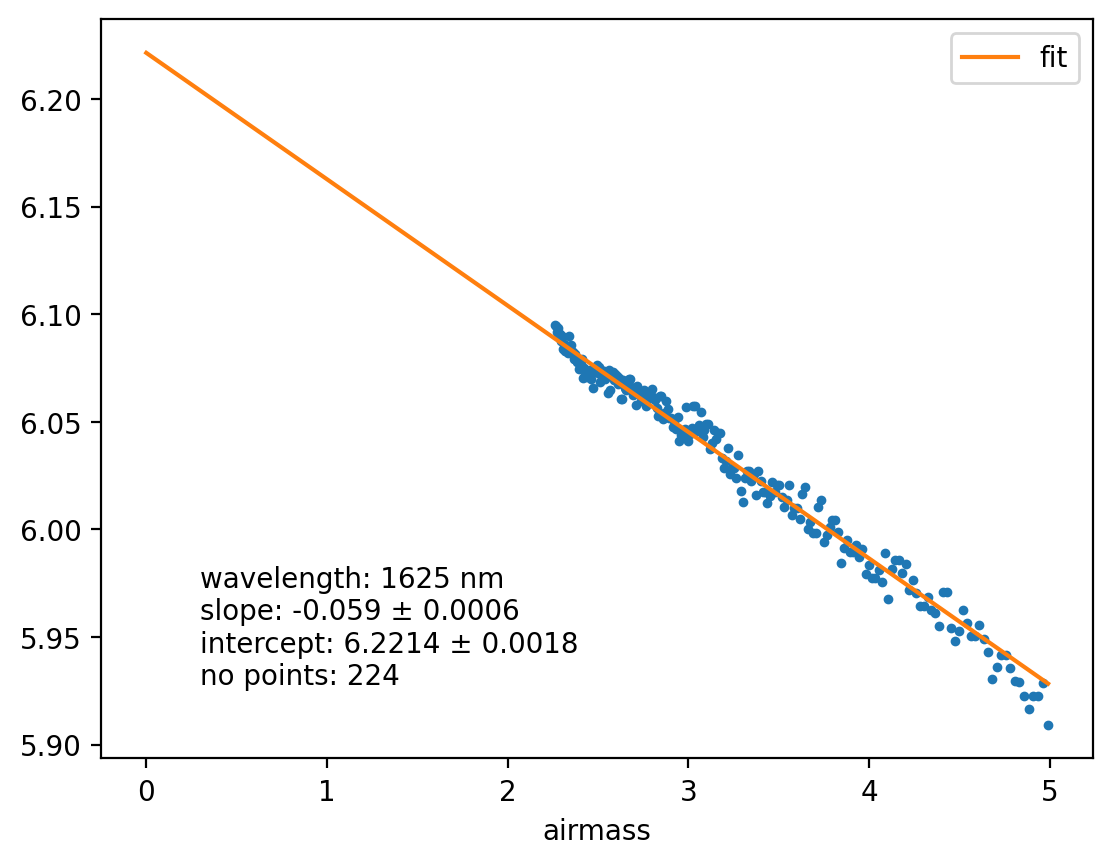

In [34]:
si_tu.direct_normal_irradiation.langley_pm.plot(wavelength=1625, show_pre_clean=False)

In [35]:
df = pd.DataFrame()
df['dscc_am'] = dscc.direct_normal_irradiation.langley_am.langley_fitres.intercept
df['tu_am'] = si_tu.direct_normal_irradiation.langley_am.langley_fitres.intercept
df['dscc_pm'] = dscc.direct_normal_irradiation.langley_pm.langley_fitres.intercept
df['tu_pm'] = si_tu.direct_normal_irradiation.langley_pm.langley_fitres.intercept

# df['tu_ratio'] = df.tu_am/df.tu_pm
# df['tu_dif'] = df.tu_am - df.tu_pm
# df['dscc_dif'] = df.dscc_am - df.dscc_pm

df['tu_dif'] = np.exp(df.tu_am) - np.exp(df.tu_pm)
df['dscc_dif'] = np.exp(df.dscc_am) - np.exp(df.dscc_pm)

df['tu_uc'] = df.tu_dif / np.exp(df.tu_am)
df['dscc_uc'] = df.dscc_dif / np.exp(df.dscc_am)

df['tuVSdscc'] = abs(((np.exp(df['dscc_am']) + np.exp(df['dscc_pm']))/2) - ((np.exp(df['tu_am']) + np.exp(df['tu_pm']))/2))
df['tuVSdscc_rel'] = df.tuVSdscc / np.exp((df['dscc_am'] + df['dscc_pm'])/2)

df

,dscc_am,tu_am,dscc_pm,tu_pm,tu_dif,dscc_dif,tu_uc,dscc_uc,tuVSdscc,tuVSdscc_rel
wavelength,,,,,,,,,,
415,7.674487,7.673400,7.740129,7.742783,-154.497208,-146.049367,-0.071846,-0.067844,1.884705,0.000847
500,7.429405,7.427375,7.487367,7.487896,-104.901596,-100.540267,-0.062390,-0.059675,1.236898,0.000713
670,7.886989,7.886693,7.935468,7.935770,-133.884443,-132.250584,-0.050302,-0.049673,0.027890,0.000010
870,7.261245,7.261404,7.305275,7.305000,-63.464860,-64.101557,-0.044560,-0.045014,0.091262,0.000063
940,7.504496,7.504151,7.620188,7.619568,-222.119230,-222.755312,-0.122342,-0.122650,0.945281,0.000491
1625,6.221581,6.221666,6.221765,6.221444,0.111852,-0.092610,0.000222,-0.000184,0.059674,0.000119
